New Machine Learning project: InsightFlow — Predictive Analytics and Modeling

In this assignment i will:

* load a dataset
* prepare a machine learning model to make predictions
* train the model on the data and make predictions
* evaluate the predictions of the model





I start by preparing the notebook in two steps.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline

In [ ]:
SEED = 1234
np.random.seed(SEED)



I will use a dataset stored in 'heart-disease.csv'. This dataset contains anonymous patient data and whether or not the patients have a heart condition.

The URL to get the data is: https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv


In [ ]:
# Import the heart disease dataset and store it in a variable
# Use pandas and read_csv()
# I can pass the URL of a csv directly to read_csv()
df=pd.read_csv('https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv')
# Check the first 5 rows of the data
df.head(5)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0




Examination of  the dataset. Resolve any issues with missing values or incorrect data types. I look at the distribution of the target column.

In [ ]:
df.dtypes
df.isna().sum()
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df['target'].value_counts()

,count
target,
1,165
0,138


Explore the dataset using visualization as create a correlation matrix to explore the relationships between variables.

In [ ]:
corr=df.corrwith(df['target']).sort_values(ascending=False)
corr



,0
target,1.000000
cp,0.433798
thalach,0.421741
slope,0.345877
restecg,0.137230
fbs,-0.028046
chol,-0.085239
trestbps,-0.144931
age,-0.225439
sex,-0.280937


In [ ]:
#I decide to eliminate the fbs and chol columns which have a low correlation
df=df.drop(columns=['fbs','chol'])
df

,age,sex,cp,trestbps,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,0,150,0,2.3,0,0,1,1
1,37,1,2,130,1,187,0,3.5,0,0,2,1
2,41,0,1,130,0,172,0,1.4,2,0,2,1
3,56,1,1,120,1,178,0,0.8,2,0,2,1
4,57,0,0,120,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,1,123,1,0.2,1,0,3,0
299,45,1,3,110,1,132,0,1.2,1,0,3,0
300,68,1,0,144,1,141,0,3.4,1,2,3,0
301,57,1,0,130,1,115,1,1.2,1,1,3,0


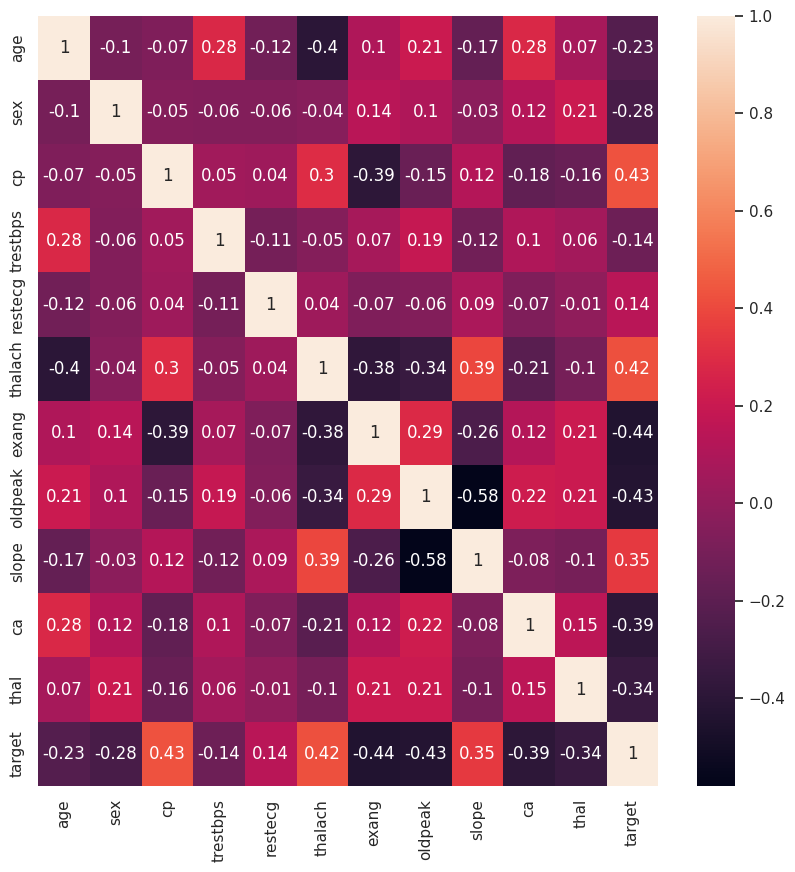

In [ ]:
correlation_matrix=df.corr().round(2)
plt.figure(figsize=(10,10))
sns.heatmap(data=correlation_matrix,annot=True)
plt.show()

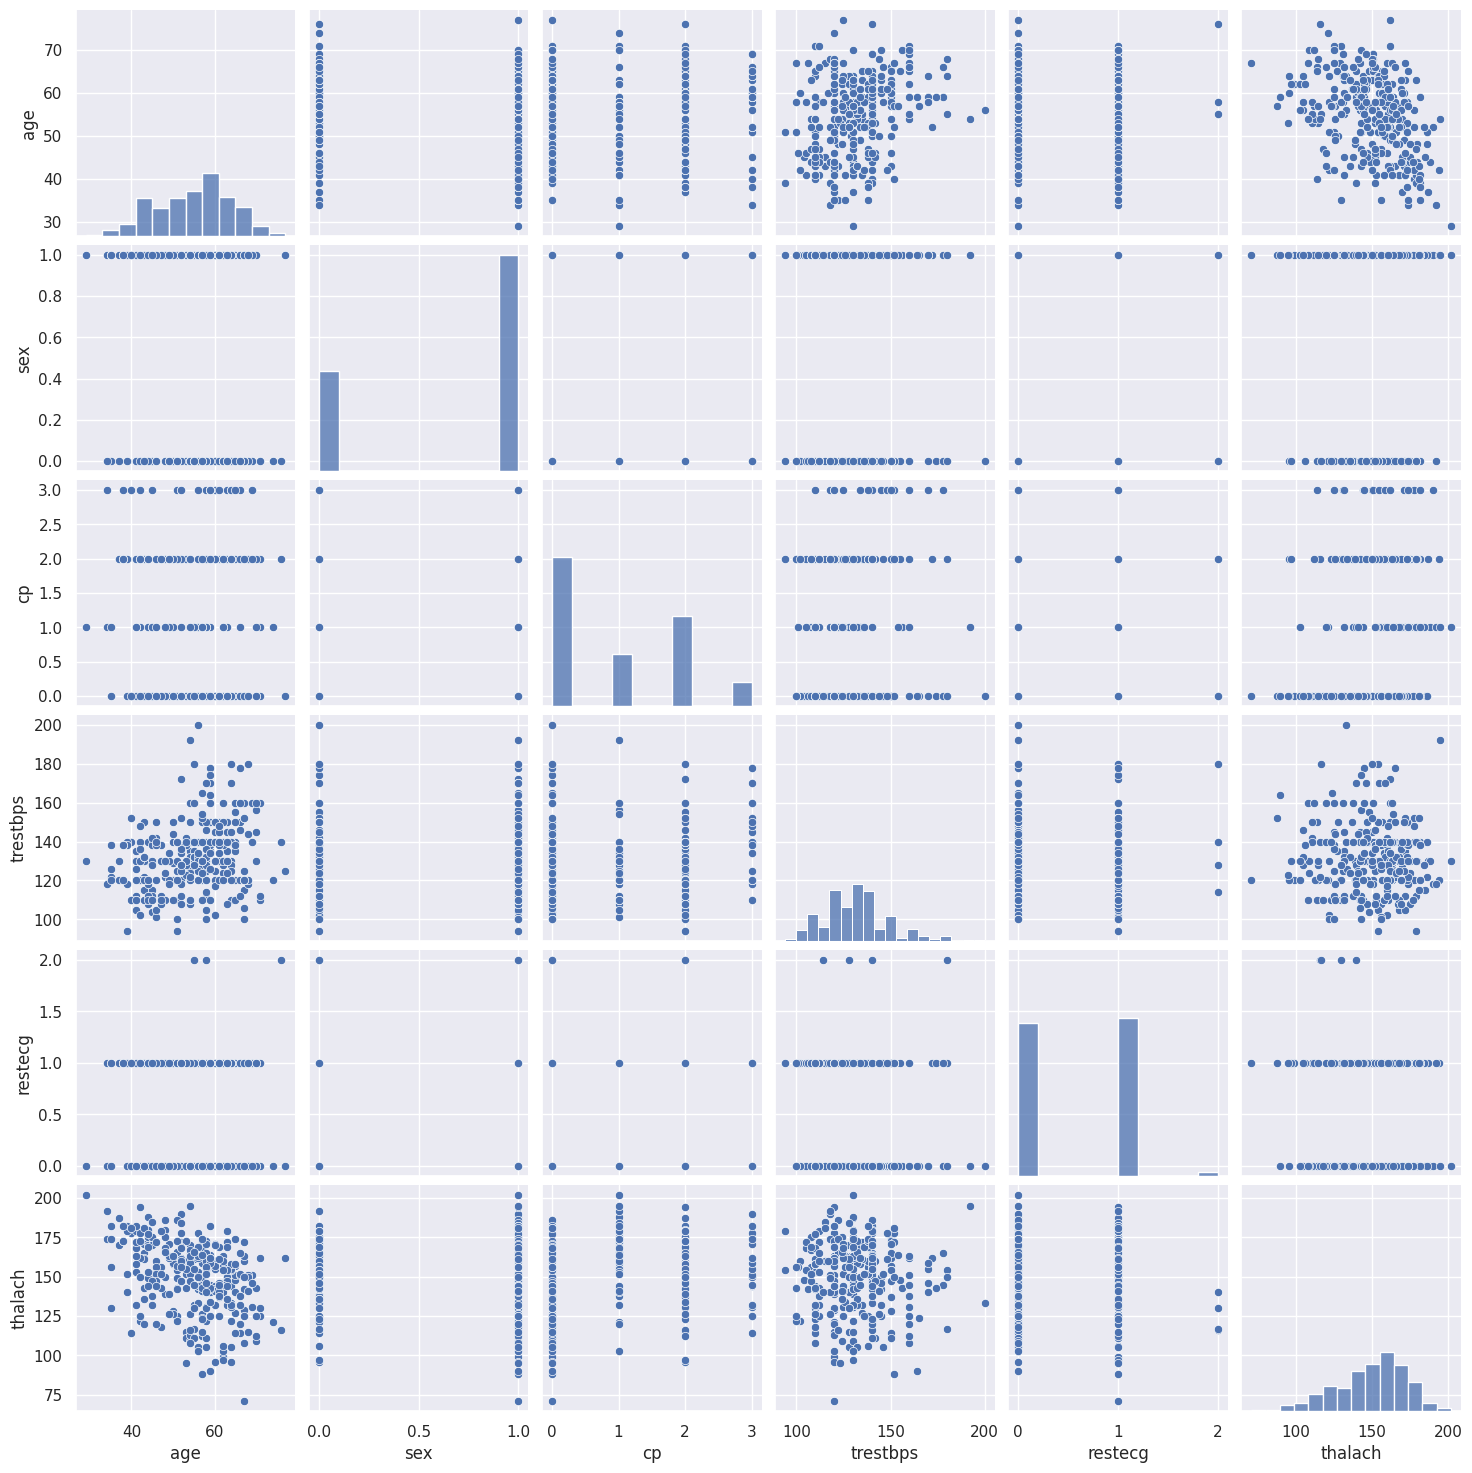

In [ ]:
sns.pairplot(data=df.iloc[: ,[0,1,2,3,4,5]])
plt.show()

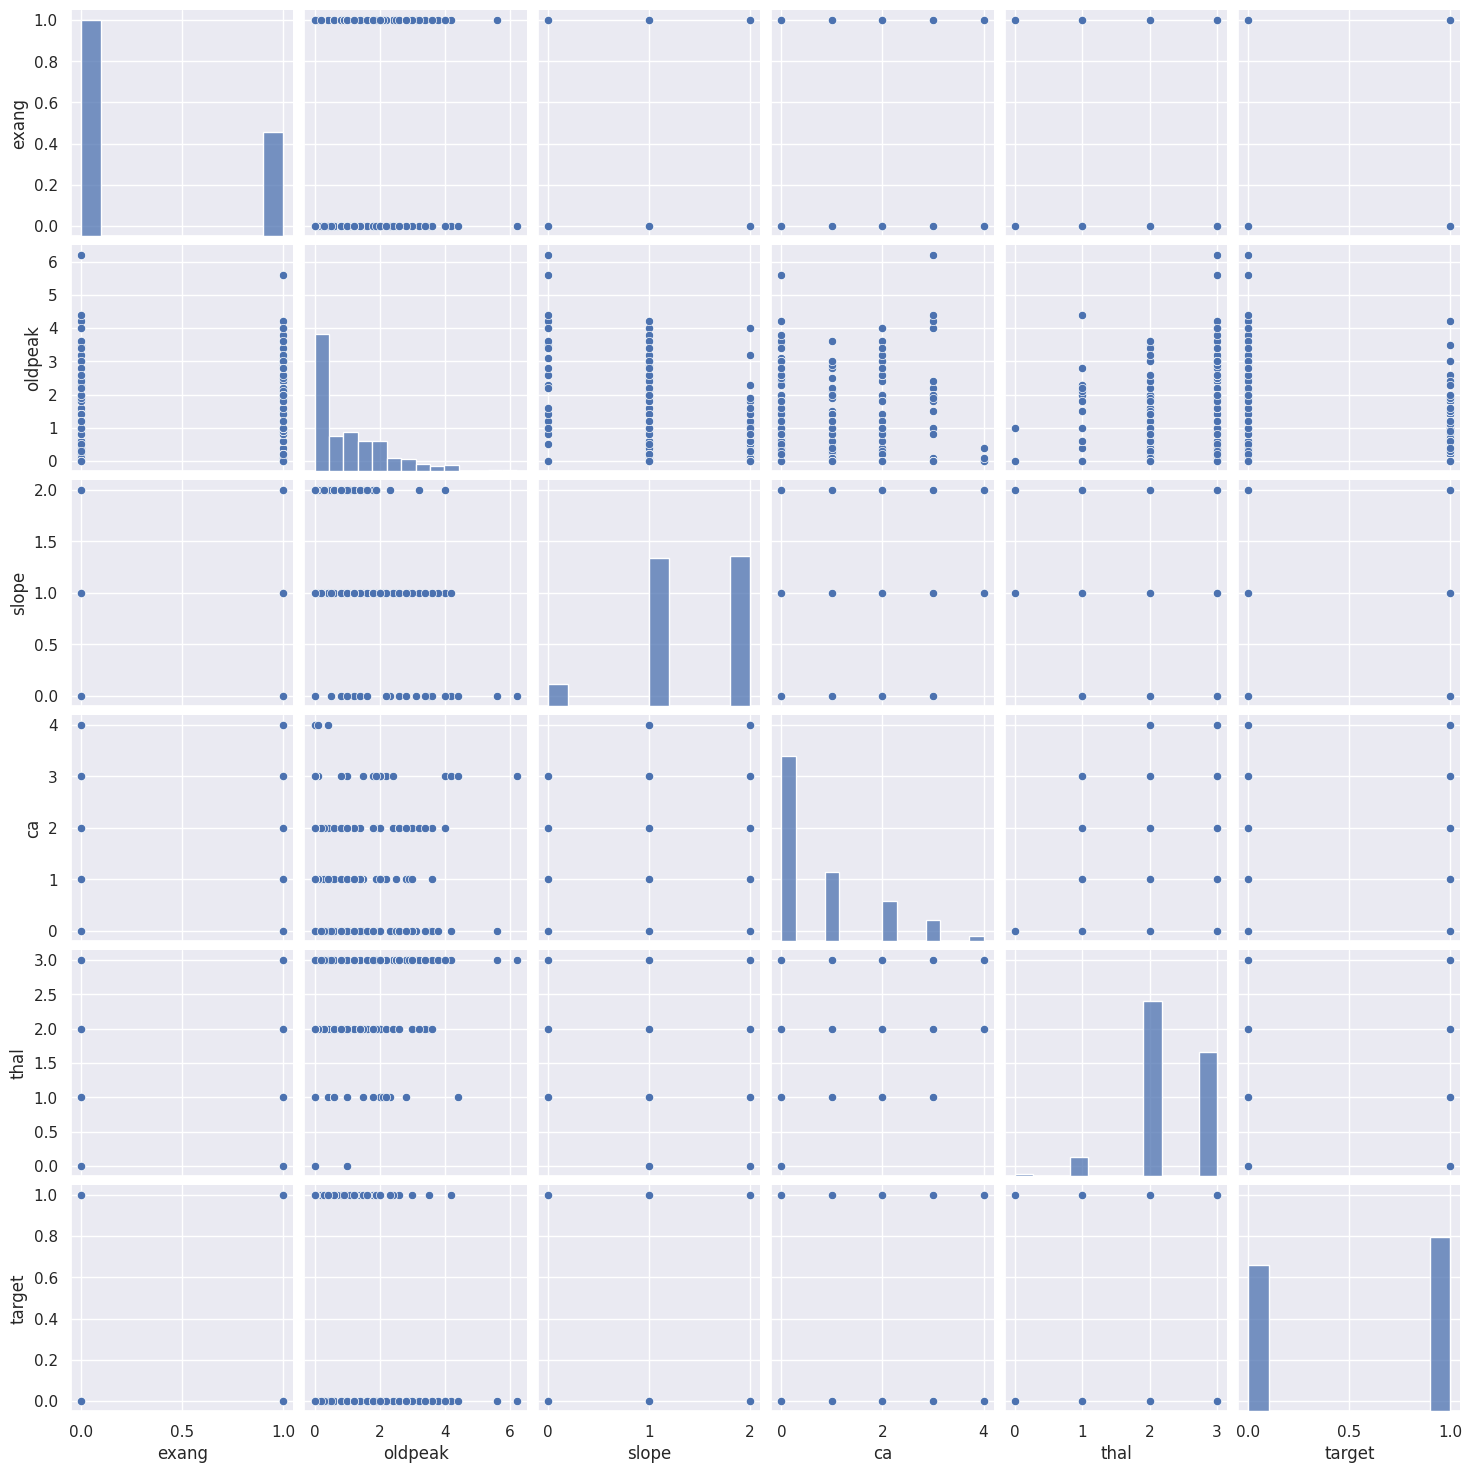

In [ ]:
sns.pairplot(data=df.iloc[: ,[6,7,8,9,10,11]])
plt.show()

In [ ]:
#I perform a logarithmic transformation on columns 5 and 7
df.iloc[:,[5,7]]=np.log1p(df.iloc[:,[5,7]])


/tmp/ipython-input-424541410.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      5.017280
1      5.236442
2      5.153292
3      5.187386
4      5.099866
         ...   
298    4.820282
299    4.890349
300    4.955827
301    4.753590
302    5.164786
Name: thalach, Length: 303, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:,[5,7]]=np.log1p(df.iloc[:,[5,7]])


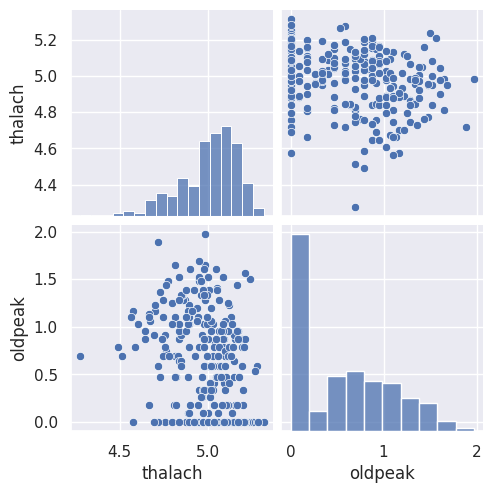

In [ ]:
sns.pairplot(data=df.iloc[: ,[5,7]])
plt.show()

 Let's prepare the dataset for analysis.



My goal is to train a machine learning model on the independent variables/features, with the aim of predicting the target.

In [ ]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['target'])
y=df['target']

Use a split of 70% train and 30% test.

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=SEED)

In [ ]:
  # Check the results of the split
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((212, 11), (91, 11), (212,), (91,))

Let's try with logistic regression

In [ ]:
# Import your chosen model from the sklearn-library
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
#Since it is a binary problem (patient is sick or not), we can perform a logistic regression
#before initializing I perform the standard scaler
scaler=StandardScaler()
X_train_scaler=scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)
# Initialize a model, giving it a suiting name
log_reg=LogisticRegression()

In [ ]:
# Train the model
log_reg.fit(X_train_scaler,y_train)




LogisticRegression()

Prediction

In [ ]:
# save the predictions in a variable called y_preds
y_preds=log_reg.predict(X_test_scaler)


              precision    recall  f1-score   support

           0       0.71      0.72      0.72        40
           1       0.78      0.76      0.77        51

    accuracy                           0.75        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.75      0.75      0.75        91

Accuracy: 0.7472527472527473
Precision: 0.78
Recall: 0.7647058823529411
F1-score: 0.7722772277227723


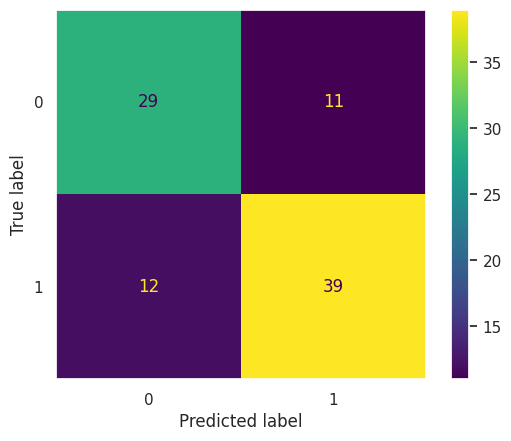

In [ ]:
# Evaluate the trained model on the testset
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay, classification_report,confusion_matrix
print(classification_report(y_test,y_preds))
print(f'Accuracy: {accuracy_score(y_test,y_preds)}')
print(f'Precision: {precision_score(y_test,y_preds)}')
print(f'Recall: {recall_score(y_test,y_preds)}')
print(f'F1-score: {f1_score(y_test,y_preds)}')
cm=confusion_matrix(y_test,y_preds)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log_reg.classes_)
display.plot()
plt.grid(False)
plt.show()

In [ ]:
# Compare the results to the results of a benchmark/baseline (use a dummy)
from sklearn.dummy import DummyClassifier
dummy=DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaler,y_train)
y_preds_dummy=dummy.predict(X_test_scaler)
print(f'Accuracy: {accuracy_score(y_test,y_preds_dummy)}')

Accuracy: 0.5604395604395604


To evaluate my logistic regression model, I used a classification report that gives me the results of the accuracy, precision, and F1 index.
Then I displayed a confusion matrix.
From the results I can deduce that:
- the model correctly classifies 75% of the total cases
- Precision(class1) when the model predicts disease it is right 78% of the time
- Recall(class1)The model finds 76% of patients who actually have the disease
- F1 good balance between precision and recall



In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(log_reg,param_grid={'C':[0.001,0.01,0.1,1,10,100]},cv=5)
grid.fit(X_train_scaler,y_train)
grid.best_params_


{'C': 0.1}

              precision    recall  f1-score   support

           0       0.78      0.72      0.75        40
           1       0.80      0.84      0.82        51

    accuracy                           0.79        91
   macro avg       0.79      0.78      0.79        91
weighted avg       0.79      0.79      0.79        91

Accuracy: 0.7912087912087912


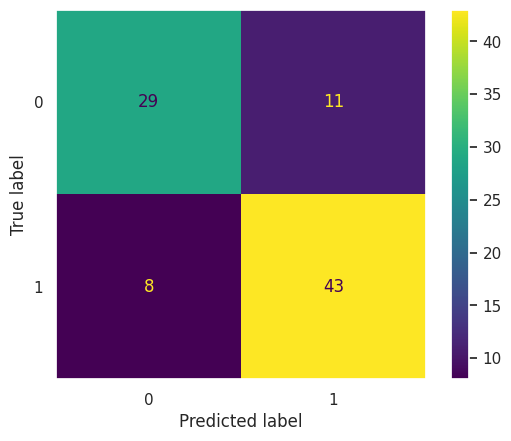

In [ ]:
log_reg=LogisticRegression(C=0.1)
log_reg.fit(X_train_scaler,y_train)
y_preds=log_reg.predict(X_test_scaler)
print(classification_report(y_test,y_preds))
print(f'Accuracy: {accuracy_score(y_test,y_preds)}')
cm=confusion_matrix(y_test,y_preds)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=log_reg.classes_)
display.plot()
plt.grid(False)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(log_reg,X_train_scaler,y_train,cv=5)
scores
print(f"Media Accuracy: {scores.mean():.3f} ± {scores.std():.3f}\n")

Media Accuracy: 0.845 ± 0.048



By inserting the correct hyperparameters the model correctly classified 4.5% more cases than before.This means how important it is to find and balance the correct Hyperparameters, even if in my case I used only 1.

I calculated the cross validation score and I will compare it later with another model to evaluate which one to choose.

Now let's try the decision tree model.

              precision    recall  f1-score   support

           0       0.67      0.72      0.70        40
           1       0.77      0.73      0.75        51

    accuracy                           0.73        91
   macro avg       0.72      0.73      0.72        91
weighted avg       0.73      0.73      0.73        91

Accuracy: 0.7252747252747253


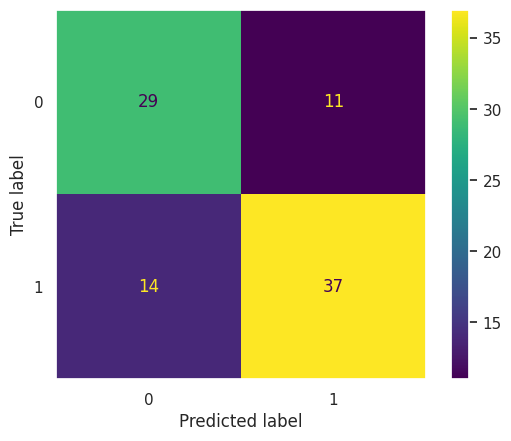

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

dec_tree=tree.DecisionTreeClassifier()
dec_tree.fit(X_train_scaler,y_train)
y_preds=dec_tree.predict(X_test_scaler)
print(classification_report(y_test,y_preds))
print(f'Accuracy: {accuracy_score(y_test,y_preds)}')
cm=confusion_matrix(y_test,y_preds)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dec_tree.classes_)
display.plot()
plt.grid(False)
plt.show()

In [ ]:
greedtree=GridSearchCV(dec_tree,param_grid={'max_depth':[1,2,3,4,5,6,7,8,9,10]},cv=5)
greedtree.fit(X_train_scaler,y_train)
greedtree.best_params_



{'max_depth': 3}

              precision    recall  f1-score   support

           0       0.87      0.68      0.76        40
           1       0.78      0.92      0.85        51

    accuracy                           0.81        91
   macro avg       0.83      0.80      0.80        91
weighted avg       0.82      0.81      0.81        91

Accuracy: 0.8131868131868132


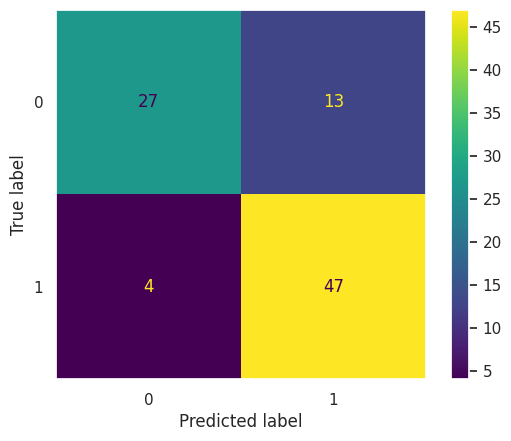

0.8131868131868132

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dec_tree=tree.DecisionTreeClassifier(max_depth=3)
dec_tree.fit(X_train_scaler,y_train)
y_preds=dec_tree.predict(X_test_scaler)
print(classification_report(y_test,y_preds))
print(f'Accuracy: {accuracy_score(y_test,y_preds)}')
cm=confusion_matrix(y_test,y_preds)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=dec_tree.classes_)
display.plot()
plt.grid(False)
plt.show()


We perform cross-validation to test the robustness of our model

In [ ]:
#we evaluate the model with logistic regression (cross validation score)
scores=cross_val_score(dec_tree,X_train_scaler,y_train,cv=5)
scores
print(f"Media Accuracy: {scores.mean():.3f} ± {scores.std():.3f}\n")


Media Accuracy: 0.830 ± 0.049



The standard deviation is 0.049 which means that the model is quite stable (there is no overfitting).But compared to logistic regression it is slightly less accurate.
With the decision tree, we have a further increase in the accuracy, precision, and recall of our model compared to logistic regression. We deduce that this model is more reliable.
Now let's visualize the decision tree.

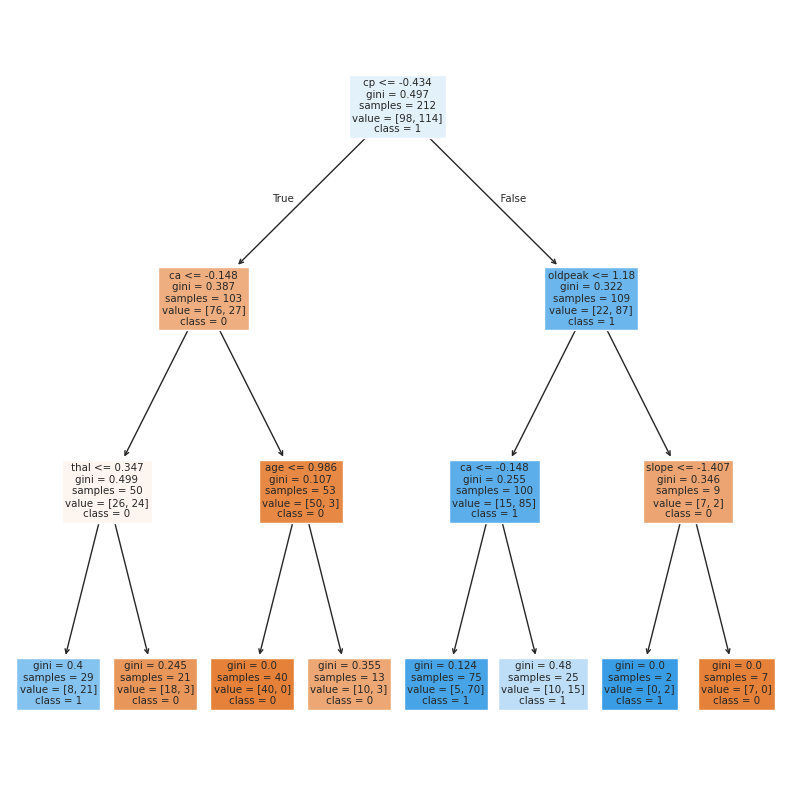

In [ ]:
class_name_str=[str(i)for i in y]
plt.figure(figsize=(10,10))
tree.plot_tree(dec_tree,feature_names=X.columns,class_names=sorted(set(class_name_str)), filled=True)
plt.show()

We visualize which are the most important features for the model and send them to the screen

In [ ]:
tree_importance=dec_tree.feature_importances_
tree_importance=pd.Series(tree_importance,index=X.columns).sort_values(ascending=False)
tree_importance

,0
cp,0.485221
ca,0.213509
thal,0.131236
oldpeak,0.103768
slope,0.049604
age,0.016662
sex,0.000000
exang,0.000000
thalach,0.000000
restecg,0.000000


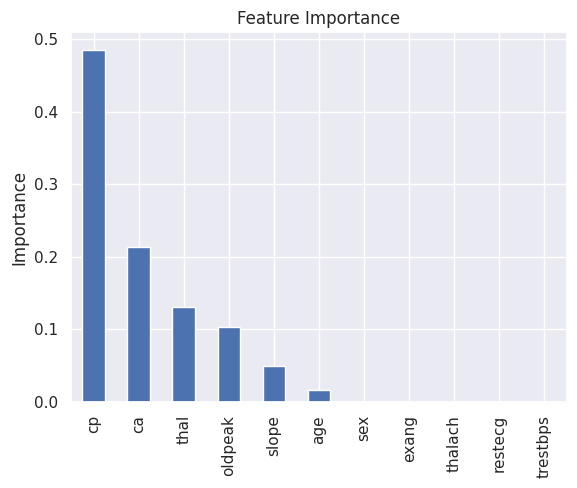

In [ ]:
fig,ax=plt.subplots()
tree_importance.plot.bar(ax=ax)
ax.set_title('Feature Importance')
ax.set_ylabel('Importance')
plt.show()


**Final considerations**

Two types of possible errors to considerate:

False Negative: the model ignores a positive patient, saying "healthy" when in reality they are ill.
Consequence: the patient does not receive timely care or treatment, which can have serious repercussions on their health.

False Positive: the model overdiagnoses, saying "ill" when in reality they are healthy.
Consequence: the patient suffers anxiety, further tests, or unnecessary treatments, but is not directly in danger of dying.

Therefore, in medicine, it is more important to consider reducing the number of false negatives.
Essentially, maximizing Recall (sensitivity).
With cross-validation, we evaluate which model is actually better. Both models excel, but if I have to rely on the model with the fewest false positives (i.e., identifies more sick patients), I would choose the logistic regression, following the reasoning above.
